In [101]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [102]:
# Load Dataset
df = pd.read_csv('../data/q3_retail_promotions.csv')

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [103]:
# Task 1. Date Feature Engineering

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create month-end flag
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [104]:
# Task 2. Temporal Train-Test Split

# Sort by date
df = df.sort_values('transaction_date').reset_index(drop=True)

# Use latest 20% as test data
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (960, 13)
Test Shape : (240, 13)


### Why a random split is inappropriate for time-ordered data
A random split is not appropriate here because the data is time-ordered. If future records are randomly mixed into the training set, the model may indirectly learn patterns from the future, which leads to data leakage and overly optimistic performance estimates. This leads to unrealistic model performance because the model learns from data that would not be available at prediction time.  
A temporal split trains on older data and tests on newer unseen data, which better reflects real-world forecasting.

In [105]:
# Task 3. Preprocessing Pipeline

X_train = train_df.drop('items_sold', axis=1)
X_test = test_df.drop('items_sold', axis=1)
y_train = train_df['items_sold']
y_test = test_df['items_sold']

# Since transaction_date has already been converted into useful date-based features, i dropped it before modeling.
X_train = X_train.drop('transaction_date', axis=1)
X_test = X_test.drop('transaction_date', axis=1)

categorical_features = ['promotion_type', 'location_type', 'store_size']

numerical_features = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
                      'year', 'month', 'day_of_week', 'is_month_end']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

In [106]:
# Task 4. Model Training and Evaluation

# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train model
lr_pipeline.fit(X_train, y_train)

# predict
lr_pred = lr_pipeline.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE: ", lr_mae)

Linear Regression RMSE: 27.121451164890626
Linear Regression MAE:  21.052926674588395


In [107]:
# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_estimators=200))
])

# Train model
rf_pipeline.fit(X_train, y_train)

# predict
rf_pred = rf_pipeline.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE: ", rf_mae)

Random Forest RMSE: 30.735565512868533
Random Forest MAE:  24.2175625


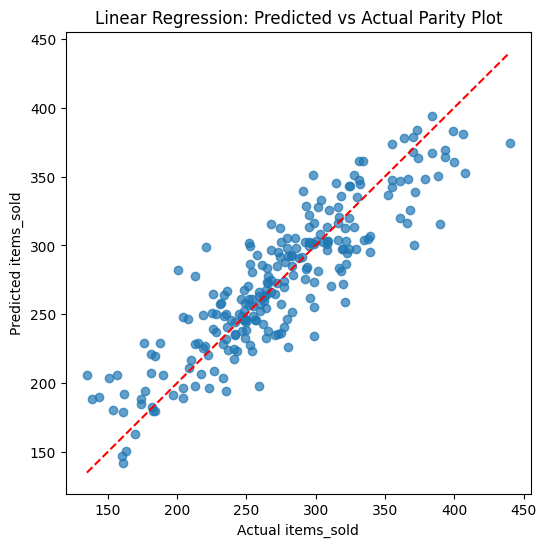

In [108]:
# Parity plot for Linear Regression
plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel('Actual items_sold')
plt.ylabel('Predicted items_sold')
plt.title('Linear Regression: Predicted vs Actual Parity Plot')
plt.show()

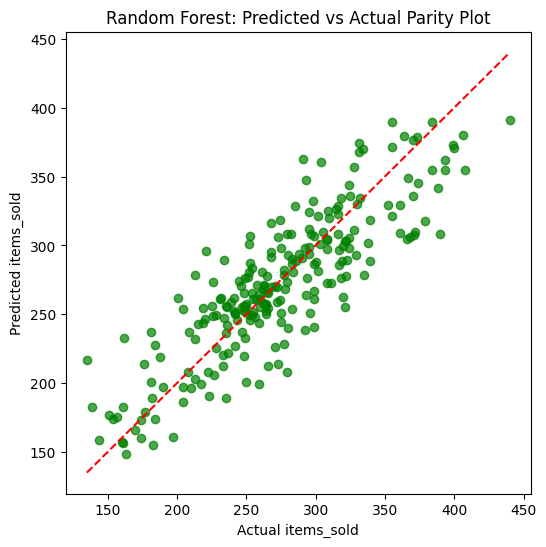

In [109]:
# Parity plot for Random Forest
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel('Actual items_sold')
plt.ylabel('Predicted items_sold')
plt.title('Random Forest: Predicted vs Actual Parity Plot')
plt.show()

In [110]:
# feature importances from the Random Forest
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Feature importances
importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(5)

,Feature,Importance
13,num__is_festival,0.176205
10,cat__store_size_small,0.163296
7,cat__location_type_urban,0.112267
17,num__day_of_week,0.085424
12,num__is_weekend,0.063098
